In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read new data
df = pd.read_csv('/home/moorche10/Desktop/note_books/divar_new.csv')
df.shape

/tmp/ipykernel_8463/1309079477.py:2: DtypeWarning: Columns (16,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/moorche10/Desktop/note_books/divar_new.csv')


(424442, 37)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424442 entries, 0 to 424441
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                424442 non-null  object 
 1   cat3_slug                424442 non-null  object 
 2   city_slug                424442 non-null  object 
 3   neighborhood_slug        424442 non-null  object 
 4   user_type                424442 non-null  object 
 5   description              424442 non-null  object 
 6   title                    424442 non-null  object 
 7   price_mode               424442 non-null  object 
 8   price_value              424442 non-null  float64
 9   land_size                424442 non-null  float64
 10  building_size            424442 non-null  float64
 11  deed_type                424442 non-null  object 
 12  floor                    424442 non-null  float64
 13  rooms_count              424442 non-null  float64
 14  tota

In [4]:
df.describe()

,price_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,location_latitude,location_longitude
count,4.244420e+05,4.244420e+05,4.244420e+05,424442.000000,424442.000000,424442.000000,424442.000000,424442.000000,424442.000000
mean,1.547958e+10,1.483944e+03,1.085004e+03,2.894167,3.087694,4.981347,2.147504,35.125567,51.563406
std,5.286585e+11,7.627807e+04,6.493766e+04,1.871161,0.841966,1.827631,0.957505,1.755553,2.433289
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000,1.000000,2.000000,1.000000,23.636976,43.774818
25%,1.720000e+09,7.700000e+01,7.500000e+01,2.000000,3.000000,5.000000,2.000000,35.046600,51.020851
50%,3.100000e+09,1.050000e+02,1.000000e+02,3.000000,3.000000,5.000000,2.000000,35.297815,51.546260
75%,6.050000e+09,1.600000e+02,1.370000e+02,3.000000,3.000000,5.000000,2.000000,35.772238,51.546260
max,1.000000e+14,1.000000e+07,1.000000e+07,30.000000,6.000000,30.000000,8.000000,40.358055,62.558594


In [5]:
# Only numeric cols
df=df.drop(["cat2_slug","cat3_slug","city_slug","neighborhood_slug","user_type","description","title",
           "price_mode","deed_type","has_balcony","has_elevator","has_warehouse","has_parking",
           "is_rebuilt","has_water","has_warm_water_provider","has_electricity","has_gas","has_heating_system",
           "has_cooling_system","has_restroom","has_barbecue","building_direction","has_pool","has_jacuzzi",
           "has_sauna","floor_material"],axis=1)
df.shape

(424442, 10)

In [6]:
df=df.drop(["location_latitude","location_longitude"],axis=1)

In [7]:
df["construction_year"].unique()

array(['۱۳۸۴', '۱۴۰۳', '۱۳۹۳', '۱۳۹۶', '۱۳۸۷', '۱۴۰۲', '۱۳۸۸', '۱۳۹۸',
       '۱۴۰۰', '۱۳۹۲', '۱۴۰۱', '۱۳۹۴', '۱۳۸۳', '۱۳۹۹', '۱۳۹۰', '۱۳۸۵',
       '۱۳۸۲', '۱۳۹۵', '۱۳۹۱', '۱۳۸۶', '۱۳۸۰', '۱۳۷۵', '۱۳۹۷', '۱۳۷۲',
       '۱۳۷۴', 'قبل از ۱۳۷۰', '۱۳۸۹', '۱۳۷۹', '۱۳۷۱', '۱۳۸۱', '۱۳۷۳',
       '۱۳۷۸', '۱۳۷۷', '۱۳۷۶'], dtype=object)

In [8]:
df = df[~df["construction_year"].str.contains('قبل از ۱۳۷۰',na=True)]

In [9]:
def persian_to_english_numbers(text):
    if pd.isna(text):
        return text
    persian_numbers = "۰۱۲۳۴۵۶۷۸۹"
    english_numbers = "0123456789"
    translation_table=str.maketrans(persian_numbers,english_numbers)
    return str(text).translate(translation_table)
df["construction_year"]=df["construction_year"].apply(persian_to_english_numbers)
df["construction_year"]=pd.to_numeric(df["construction_year"],errors="coerce")

In [10]:
df["construction_year"].unique()

array([1384, 1403, 1393, 1396, 1387, 1402, 1388, 1398, 1400, 1392, 1401,
       1394, 1383, 1399, 1390, 1385, 1382, 1395, 1391, 1386, 1380, 1375,
       1397, 1372, 1374, 1389, 1379, 1371, 1381, 1373, 1378, 1377, 1376])

In [11]:
df.head()

,price_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,construction_year
0,8.500000e+09,60.0,60.0,3.0,2.0,5.0,2.0,1384
1,5.750000e+09,115.0,115.0,4.0,3.0,6.0,2.0,1403
2,8.700000e+09,100.0,100.0,4.0,3.0,5.0,2.0,1393
3,6.500000e+08,78.0,78.0,4.0,3.0,6.0,4.0,1396
4,3.000000e+09,80.0,80.0,3.0,3.0,5.0,2.0,1387


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
# PCA
# X = df.drop("price_value",axis=1)
# y = df["price_value"]
X = df
y = None
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
pca = PCA(n_components=8).fit(X_scaled)
pca.explained_variance_

array([1.74950972, 1.46025281, 1.15542732, 0.99920664, 0.85929974,
       0.73777081, 0.53979357, 0.49875865])

In [15]:
pca_full = PCA(n_components=8)
pca_full.fit(X_scaled)
cumulative = pca_full.explained_variance_ratio_.cumsum()
for i,cum in enumerate(cumulative,1):
    print(f"{i:2d}kamponent -> {cum:.3%} warianse")
    if cum >= 0.90 :
        print(f"با {i} کامپوننت به واریانس 90% رسیدیم")
        break

 1kamponent -> 21.869% warianse
 2kamponent -> 40.122% warianse
 3kamponent -> 54.565% warianse
 4kamponent -> 67.055% warianse
 5kamponent -> 77.796% warianse
 6kamponent -> 87.018% warianse
 7kamponent -> 93.766% warianse
با 7 کامپوننت به واریانس 90% رسیدیم


In [16]:
pca = PCA(n_components=7)
pca_features = pca.fit_transform(X_scaled)
print('Shape before PCA: ', X_scaled.shape)
print('Shape after PCA: ', pca_features.shape)

Shape before PCA:  (415486, 8)
Shape after PCA:  (415486, 7)


In [17]:
# Best Variance and n_components
pca_final = PCA(n_components=0.92)
X_pca = pca_final.fit_transform(X_scaled)
print(f"تعداد کامپوننت انتخاب شده :{pca_final.n_components_}")
print(f"واریانس حفظ شده : {pca_final.explained_variance_ratio_.sum():.3%}")

تعداد کامپوننت انتخاب شده :7
واریانس حفظ شده : 93.766%


In [18]:
pca_df=pd.DataFrame(
    data=pca_features,
    columns=["PCA1","PCA2","PCA3","PCA4","PCA5","PCA6","PCA7"])
pca_df

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7
0,-0.605722,-0.031070,-1.618150,0.178251,-0.491967,-0.788636,-0.000540
1,0.857434,-0.002608,0.535663,-0.139193,0.714955,-0.472778,-0.000521
2,0.181399,-0.021683,-0.110809,0.012155,-0.304881,-0.516352,0.003453
3,1.558537,-0.005495,-0.911313,0.040654,0.177956,0.844294,0.003002
4,-0.318788,-0.035185,-0.566471,0.093532,-0.836129,-0.240104,0.004063
...,...,...,...,...,...,...,...
415481,1.213979,-0.006211,1.823808,-0.214184,-0.201642,-0.986558,0.004222
415482,-0.445303,-0.021621,0.360347,-0.109574,0.866799,0.509896,-0.002019
415483,-0.326815,-0.033241,-0.405724,0.073398,-0.794347,-0.521703,0.005999
415484,-0.146822,-0.018180,0.391361,-0.111232,0.759535,0.188125,-0.001017


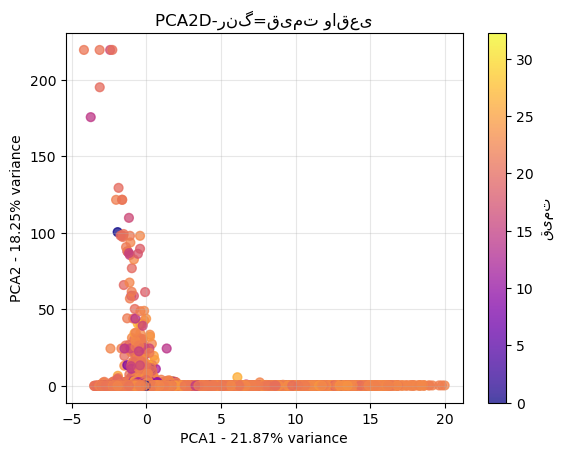

واریانس با هفت کامپوننت:40.12%


In [19]:
pca2d = PCA(n_components=2)
x_pca2d = pca2d.fit_transform(X_scaled)
viz_df = pd.DataFrame({
    "PCA1":x_pca2d[:,0],
    "PCA2":x_pca2d[:,1],
    "price":np.log1p(df["price_value"].values)})
plt.figure()
scatter = plt.scatter(viz_df["PCA1"],viz_df["PCA2"],
                      c=viz_df["price"],cmap="plasma",alpha=0.75,s=40)
plt.colorbar(scatter,label="قیمت")
plt.title("PCA2D-رنگ=قیمت واقعی")
plt.xlabel(f"PCA1 - {pca2d.explained_variance_ratio_[0]:.2%} variance")
plt.ylabel(f"PCA2 - {pca2d.explained_variance_ratio_[1]:.2%} variance")
plt.grid(True,alpha=0.3)
plt.show()
print(f"واریانس با هفت کامپوننت:{pca2d.explained_variance_ratio_.sum():.2%}")

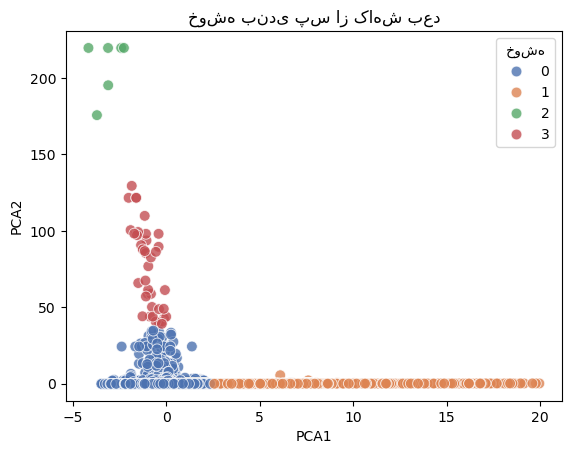

In [20]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4,random_state=42)
clusters = kmeans.fit_predict(x_pca2d)
viz_df["Cluster"]=clusters
plt.figure()
sns.scatterplot(data=viz_df,x="PCA1",y="PCA2",hue="Cluster",palette="deep",s=60,alpha=0.8)
plt.title("خوشه بندی پس از کاهش بعد")
plt.legend(title="خوشه")
plt.show()

In [21]:
# Price Value of my Clusters
viz_analyse = viz_df.copy()
viz_analyse["price_real"]=df["price_value"]
print(viz_analyse.groupby("Cluster")["price_real"].agg(["count","mean","std","min","max"]).round(0))

          count          mean           std          min           max
Cluster                                                               
0        392349  1.552132e+10  5.362061e+11          0.0  1.000000e+14
1         14302  1.033439e+10  1.804871e+11          0.0  1.111111e+13
2             6  2.517685e+09  1.379126e+09  111111111.0  4.250000e+09
3            42  7.914848e+09  1.934449e+10          0.0  1.200000e+11


In [22]:
best_n_clusters = 4
kmeans_final = KMeans(n_clusters=best_n_clusters,random_state=42,n_init=10)
clusters = kmeans_final.fit_predict(X_pca)
X_final = pd.DataFrame(X_pca,
                       columns=[f"PCA{i+1}"for i in range(pca_final.n_components_)])
X_final["Cluster"] = clusters.astype(str)
y= df["price_value"].copy()
print(f"دیتافریم نهایی آماده شد")
print(f"شکل :{X_final.shape}")
print(f"ستونها :{list(X_final.columns)}")
print(f"مقادیر یکتای ستون Cluster :{X_final["Cluster"].unique()}")
X_final.head()

دیتافریم نهایی آماده شد
شکل :(415486, 8)
ستونها :['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'Cluster']
مقادیر یکتای ستون Cluster :['0' '1' '3' '2']


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,Cluster
0,-0.605722,-0.031070,-1.618150,0.178251,-0.491967,-0.788636,-0.000540,0
1,0.857434,-0.002608,0.535663,-0.139193,0.714955,-0.472778,-0.000521,1
2,0.181399,-0.021683,-0.110809,0.012155,-0.304881,-0.516352,0.003453,0
3,1.558537,-0.005495,-0.911313,0.040654,0.177956,0.844294,0.003002,1
4,-0.318788,-0.035185,-0.566471,0.093532,-0.836129,-0.240104,0.004063,0


In [23]:
print("شکل X_pca:",X_pca.shape)

شکل X_pca: (415486, 7)


In [24]:
from sklearn.metrics import silhouette_score

In [25]:
idx = np.random.choice(len(X_pca),30000,replace=False)
X_sample = X_pca[idx]
for k in range(2,10):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample,labels)
    print(f"k={k} -> Silhouette = {score:.4f}")

k=2 -> Silhouette = 0.6222
k=3 -> Silhouette = 0.2579
k=4 -> Silhouette = 0.2593
k=5 -> Silhouette = 0.2614
k=6 -> Silhouette = 0.2794
k=7 -> Silhouette = 0.2800
k=8 -> Silhouette = 0.2810
k=9 -> Silhouette = 0.2827


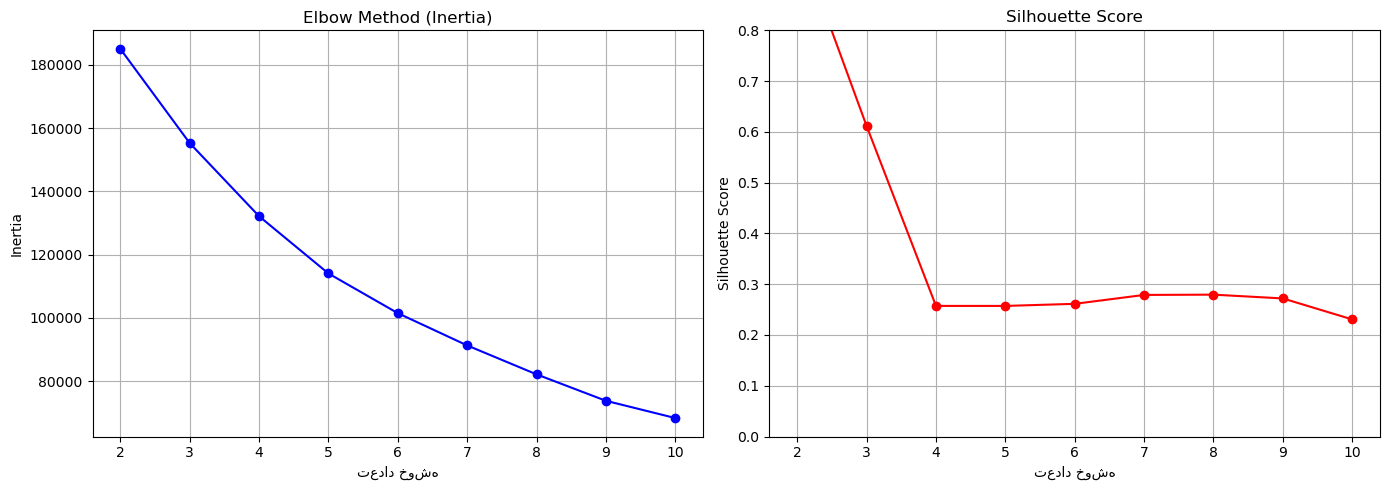

k=2 → Silhouette = 0.9847
k=3 → Silhouette = 0.6116
k=4 → Silhouette = 0.2572
k=5 → Silhouette = 0.2572
k=6 → Silhouette = 0.2613
k=7 → Silhouette = 0.2789
k=8 → Silhouette = 0.2794
k=9 → Silhouette = 0.2720
k=10 → Silhouette = 0.2306


In [26]:
# نمونه‌گیری درست
idx = np.random.choice(len(X_pca), 30000, replace=False)
X_sample = X_pca[idx]

inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels))

# دو تا نمودار جدا با مقیاس درست
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ۱. Elbow Method (Inertia)
ax1.plot(k_range, inertias, 'bo-')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('تعداد خوشه')
ax1.set_ylabel('Inertia')
ax1.grid(True)

# ۲. Silhouette Score (مقیاس درست!)
ax2.plot(k_range, sil_scores, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('تعداد خوشه')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)
ax2.set_ylim(0, 0.8)   # مهم! این خط باعث می‌شه اعداد واقعی دیده بشن

plt.tight_layout()
plt.show()

# چاپ عددها
for k, sil in zip(k_range, sil_scores):
    print(f"k={k} → Silhouette = {sil:.4f}")


In [27]:
idx = np.random.choice(len(X_pca),30000,replace=False)
X_sample = X_pca[idx]
for k in range(2,10):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample,labels)
    print(f"k={k} -> Silhouette = {score:.4f}")

k=2 -> Silhouette = 0.6176
k=3 -> Silhouette = 0.2503
k=4 -> Silhouette = 0.2597
k=5 -> Silhouette = 0.2787
k=6 -> Silhouette = 0.2801
k=7 -> Silhouette = 0.2722
k=8 -> Silhouette = 0.2804
k=9 -> Silhouette = 0.2885


In [28]:
best_n_clusters = 4
kmeans_final = KMeans(n_clusters=best_n_clusters,random_state=42,n_init=15)
clusters = kmeans_final.fit_predict(X_pca)
X_final = pd.DataFrame(X_pca,
                       columns=[f"PCA{i+1}"for i in range(pca_final.n_components_)])
X_final["Cluster"] = clusters.astype(str)
y= df["price_value"].copy()
print(f"دیتافریم نهایی آماده شد")
print(f"شکل :{X_final.shape}")
print(f"ستونها :{list(X_final.columns)}")
print(f"مقادیر یکتای ستون Cluster :{X_final["Cluster"].unique()}")
print("########################################")
print(f"توزیخ خوشه ها؛:")
print(X_final["Cluster"].value_counts().sort_index())
print(f"\nمقادیر یکتا",sorted(X_final["Cluster"].unique()))
print(f"شکل نهایی دیتافریم:",X_final.shape)
print(f"n\چند ردیف نخست:",X_final.head())
X_final.head()

دیتافریم نهایی آماده شد
شکل :(415486, 8)
ستونها :['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'Cluster']
مقادیر یکتای ستون Cluster :['0' '1' '3' '2']
########################################
توزیخ خوشه ها؛:
Cluster
0    175521
1    225088
2        36
3     14841
Name: count, dtype: int64

مقادیر یکتا ['0', '1', '2', '3']
شکل نهایی دیتافریم: (415486, 8)
n\چند ردیف نخست:        PCA1      PCA2      PCA3      PCA4      PCA5      PCA6      PCA7  \
0 -0.605722 -0.031070 -1.618150  0.178251 -0.491967 -0.788636 -0.000540   
1  0.857434 -0.002608  0.535663 -0.139193  0.714955 -0.472778 -0.000521   
2  0.181399 -0.021683 -0.110809  0.012155 -0.304881 -0.516352  0.003453   
3  1.558537 -0.005495 -0.911313  0.040654  0.177956  0.844294  0.003002   
4 -0.318788 -0.035185 -0.566471  0.093532 -0.836129 -0.240104  0.004063   

  Cluster  
0       0  
1       1  
2       0  
3       1  
4       0  


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,Cluster
0,-0.605722,-0.031070,-1.618150,0.178251,-0.491967,-0.788636,-0.000540,0
1,0.857434,-0.002608,0.535663,-0.139193,0.714955,-0.472778,-0.000521,1
2,0.181399,-0.021683,-0.110809,0.012155,-0.304881,-0.516352,0.003453,0
3,1.558537,-0.005495,-0.911313,0.040654,0.177956,0.844294,0.003002,1
4,-0.318788,-0.035185,-0.566471,0.093532,-0.836129,-0.240104,0.004063,0


In [29]:
from sklearn.mixture import GaussianMixture
best_n_clusters = 4
gmm = GaussianMixture(n_components = best_n_clusters,
                      covariance_type = "full",
                      random_state=42 , max_iter=300 , n_init=10)
clusters = gmm.fit_predict(X_pca)
X_final = pd.DataFrame(X_pca,columns=[f"PCA{i+1}" for i in range(7)])
X_final["Cluster"] = clusters.astype(int)
print("توزیع خوشه با GMM")
print(X_final["Cluster"].value_counts().sort_index())

توزیع خوشه با GMM
Cluster
0    251470
1     21544
2    138884
3      3588
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_percentage_error
X_train,X_test,y_train,y_test = train_test_split(X_final,y,test_size=0.2,random_state=42,stratify=X_final["Cluster"])

In [31]:
print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))

X_train shape: (332388, 8)
y_train shape: (332388,)


In [32]:
print("X_test shape: {}".format(X_test.shape))
print("y_test shape: {}".format(y_test.shape))

X_test shape: (83098, 8)
y_test shape: (83098,)


In [33]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=None,random_state=42)
model.fit(X_train,y_train)
pred = model.predict(X_test)
r2 = r2_score(y_test,pred)
mape = mean_absolute_percentage_error(y_test,pred)
print("Decision Tree -> R2 :",round(r2,4),"| MAPE :",f"{mape:.2%}")

Decision Tree -> R2 : 0.994 | MAPE : 730966513580082689212416.00%


In [34]:
# K-Nearest Neighbors Regressor
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5,n_jobs= -1)
model.fit(X_train,y_train)
pred = model.predict(X_test)
r2 = r2_score(y_test,pred)
mape = mean_absolute_percentage_error(y_test,pred)
print("KNN Regressor -> R2 :",round(r2,4),"| MAPE :",f"{mape:.2%}")

KNN Regressor -> R2 : 0.9861 | MAPE : 2039868096242649715965952.00%


In [35]:
# XGBoost Regressor
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators = 1500 , learning_rate=0.03,max_depth=10,
                     subsample=0.9 , colsample_bytree=0.9,
                     random_state=42 , n_jobs= -1,tree_method="hist")
model.fit(X_train,y_train)
pred = model.predict(X_test)
r2 = r2_score(y_test,pred)
mape = mean_absolute_percentage_error(y_test,pred)
print("XGBoost -> R2 :",round(r2,4),"| MAPE :",f"{mape:.2%}")

XGBoost -> R2 : 0.9332 | MAPE : 1543737510504003931209728.00%


In [37]:
# LightGBM Regressor
from lightgbm import LGBMRegressor
model = LGBMRegressor(n_estimators=1500 , learning_rate=0.03, num_leaves=256,
                      subsample =0.9 , colsample_bytree=0.9,
                      random_state=42,n_jobs= -1)
model.fit(X_train,y_train)
pred = model.predict(X_test)
r2 = r2_score(y_test,pred)
mape = mean_absolute_percentage_error(y_test,pred)
print("LightGBM -> R2 :",round(r2,4),"| MAPE :",f"{mape:.2%}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 332388, number of used features: 8
[LightGBM] [Info] Start training from score 15798849414.723528
LightGBM -> R2 : 0.9397 | MAPE : 5741111776566280294760448.00%


In [38]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 400, max_depth=20 , n_jobs= -1 , random_state=42)
model.fit(X_train,y_train)
pred = model.predict(X_test)
r2 = r2_score(y_test,pred)
mape = mean_absolute_percentage_error(y_test,pred)
print("Random Forest ->R2 :",round(r2,4),"| MAPE :",f"{mape:.2%}")

Random Forest ->R2 : 0.9988 | MAPE : 3567361191914767040643072.00%


In [48]:
from sklearn.metrics import r2_score,mean_absolute_percentage_error
model ={
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=None,random_state=42),
    "K-Nearest Neighbors Regressor": KNeighborsRegressor(n_neighbors=5,n_jobs= -1),
    "XGBoost Regressor": XGBRegressor(n_estimators = 1500 , learning_rate=0.03,max_depth=10,
                     subsample=0.9 , colsample_bytree=0.9,
                     random_state=42 , n_jobs= -1,tree_method="hist"),
    "LightGBM Regressor":LGBMRegressor(n_estimators=1500 , learning_rate=0.03, num_leaves=256,
                      subsample =0.9 , colsample_bytree=0.9,
                      random_state=42,n_jobs= -1),
    "Random Forest Regressor": RandomForestRegressor(n_estimators = 400, max_depth=20 , n_jobs= -1 , random_state=42)}
results=[]
print("درحال مقایسه مدلها روی Train و Test ...\n"+"-"*70)
for name,model in model.items():
    model.fit(X_train,y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    r2_train=r2_score(y_train,pred_train)
    r2_test = r2_score(y_test,pred_test)
    mape_test = mean_absolute_percentage_error(y_test,pred_test)
    diff = r2_train - r2_test
    if diff > 0.05:
        status = "اورفیت زیاد"
    elif diff > 0.02 :
        status = "اورفیت متوسط"
    else:
        status = "بدون اورفیت"
    results.append({
        "مدل":model ,
        "R2 Train": round(r2_train,4),
        "R2 Test":round(r2_test,4),
        "تفاوت":round(r2_train - r2_test,4),
        "MAPE":f"{mape_test:.2%}",
        "وضعیت":status})
    print(f"{name:12}|Train R2:{r2_train:.4f}|Test R2:{r2_test:.4f}|تفاوت:{r2_train - r2_test:.4f}-> {status}")
df = pd.DataFrame(results)
df = df.sort_values("R2 Test",ascending=False).reset_index(drop=True)
print("\n"+"="*80)
print("رتبه بندی نهایی مدلها ٪٪٪ بهترین در بالا")
print("="*80)
print(df.to_string(index=False))
print("="*80)
print(f"بهترین مدل: {df.iloc[0]["مدل"]}")
print(f"R2 نهایی: :{df.iloc[0]["R2 Test"]:.4f}|MAPE: {df.iloc[0]['MAPE']}")

درحال مقایسه مدلها روی Train و Test ...
----------------------------------------------------------------------
Decision Tree Regressor|Train R2:1.0000|Test R2:0.9940|تفاوت:0.0060-> بدون اورفیت
K-Nearest Neighbors Regressor|Train R2:0.9980|Test R2:0.9861|تفاوت:0.0119-> بدون اورفیت
XGBoost Regressor|Train R2:1.0000|Test R2:0.9332|تفاوت:0.0667-> اورفیت زیاد
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 332388, number of used features: 8
[LightGBM] [Info] Start training from score 15798849414.723528
LightGBM Regressor|Train R2:0.9984|Test R2:0.9397|تفاوت:0.0588-> اورفیت زیاد
Random Forest Regressor|Train R2:0.9995|Test R2:0.9988|تفاوت:0.0008-> بدون اورفیت

رتبه بندی نهایی مدلها ٪٪٪ بهترین در بالا
                                                                                          

In [61]:
y_pred=model.predict(X_test)
y_real=y_test.values
error_percent = (y_pred - y_real)/y_real*100
results = pd.DataFrame({"قیمت واقعی":y_real,
                        "قیمت پیشبینی":y_pred,
                        "خطای درصد":error_percent,
                        "خطای مطلق":y_pred - y_real,})
def categorize_price(price):
    if price <= results["قیمت واقعی"].quantile(0.33):
        return "ارزان"
    elif price <= results["قیمت واقعی"].quantile(0.66):
        return "مناسب"
    else :
        return "گران"
results["دسته قیمت"]=results["قیمت واقعی"].apply(categorize_price)
def categorize_by_errors(err):
    if err < -15 :
        return "ارزان"
    elif -15 <= err <= 15 :
        return "مناسب"
    else :
        return "گران"
results["دسته بر اساس مدل"]= results["خطای درصد"].apply(categorize_by_errors)
print("دسته بندی بر اساس قیمت واقعی : ")
print(results["دسته قیمت"].value_counts())
print("\n دسته بندی از اساس خطای مدل : ")
print(results["دسته بر اساس مدل"].value_counts())
print("\n نمونه هایی از دسته بندی : ")
print(results[["دسته بر اساس مدل","خطای درصد","قیمت پیشبینی","قیمت واقعی","خطای مطلق"]].head())

/tmp/ipykernel_8463/1439321323.py:3: RuntimeWarning: divide by zero encountered in divide
  error_percent = (y_pred - y_real)/y_real*100


دسته بندی بر اساس قیمت واقعی : 
دسته قیمت
گران     27974
ارزان    27717
مناسب    27407
Name: count, dtype: int64

 دسته بندی از اساس خطای مدل : 
دسته بر اساس مدل
مناسب    35826
گران     33615
ارزان    13657
Name: count, dtype: int64

 نمونه هایی از دسته بندی : 
  دسته بر اساس مدل  خطای درصد  قیمت پیشبینی    قیمت واقعی     خطای مطلق
0            ارزان -56.209113  5.473861e+09  1.250000e+10 -7.026139e+09
1            مناسب   3.294116  2.980035e+09  2.885000e+09  9.503525e+07
2             گران  68.403847  6.230942e+09  3.700000e+09  2.530942e+09
3             گران  20.267883  3.367501e+09  2.800000e+09  5.675007e+08
4             گران  27.193033  3.815791e+09  3.000000e+09  8.157910e+08


In [60]:
results[["دسته بر اساس مدل","خطای درصد","قیمت پیشبینی","قیمت واقعی","خطای مطلق"]]

,دسته بر اساس مدل,خطای درصد,قیمت پیشبینی,قیمت واقعی,خطای مطلق
0,ارزان,-56.209113,5.473861e+09,1.250000e+10,-7.026139e+09
1,مناسب,3.294116,2.980035e+09,2.885000e+09,9.503525e+07
2,گران,68.403847,6.230942e+09,3.700000e+09,2.530942e+09
3,گران,20.267883,3.367501e+09,2.800000e+09,5.675007e+08
4,گران,27.193033,3.815791e+09,3.000000e+09,8.157910e+08
...,...,...,...,...,...
83093,مناسب,-1.558808,3.445442e+09,3.500000e+09,-5.455827e+07
83094,ارزان,-55.764773,6.281402e+09,1.420000e+10,-7.918598e+09
83095,گران,51.531065,3.333683e+09,2.200000e+09,1.133683e+09
83096,گران,48.427683,2.003774e+09,1.350000e+09,6.537737e+08


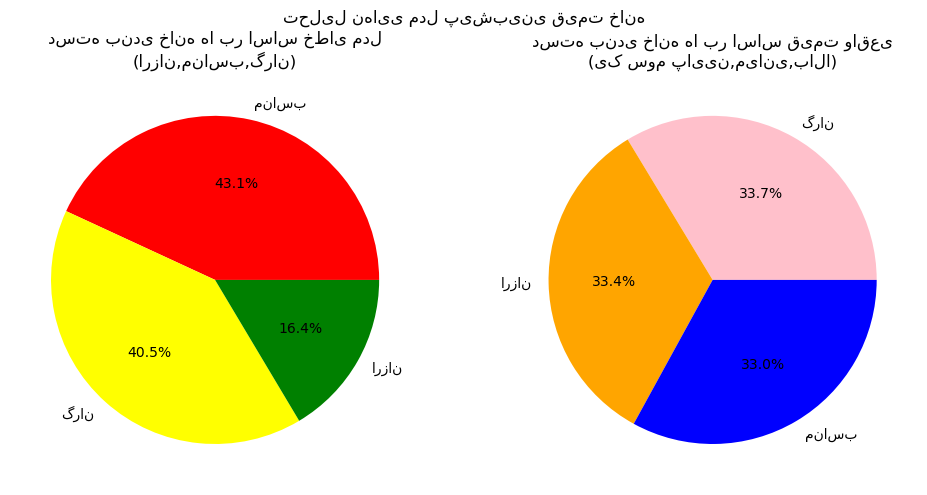


 نمونه هایی از پیشبینی مدل : 


,دسته بر اساس مدل,خطای درصد,قیمت پیشبینی,قیمت واقعی
53064,مناسب,4.791983,2095839654,2000000000
10524,گران,104.951274,3238230121,1580000000
50816,مناسب,3.255841,26505774264,25670000000
8619,مناسب,-0.784096,8929431321,9000000000
64299,مناسب,-1.554513,4725383386,4800000000
73346,مناسب,1.232848,4454245297,4400000000
14682,مناسب,-6.015478,18796904318,20000000000
39275,مناسب,-2.470830,10728208668,11000000000
42377,ارزان,-22.798423,2007241012,2600000000
19447,ارزان,-19.363553,14111378312,17500000000


In [99]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
counts1=results["دسته بر اساس مدل"].value_counts()
colors1=["red","yellow","green"]
ax1.pie(counts1.values,labels=counts1.index,autopct="%1.1f%%",colors=colors1)
ax1.set_title("دسته بندی خانه ها بر اساس خطای مدل\n(ارزان,مناسب,گران)")

counts2=results["دسته قیمت"].value_counts()
colors2=["pink","orange","blue"]
ax2.pie(counts2.values,labels=counts2.index,autopct="%1.1f%%",colors=colors2)
ax2.set_title("دسته بندی خانه ها بر اساس قیمت واقعی\n(یک سوم پایین,میانی,بالا)")

plt.suptitle("تحلیل نهایی مدل پیشبینی قیمت خانه")
plt.tight_layout()
plt.show()

print("\n نمونه هایی از پیشبینی مدل : ")
sample = results.sample(10,random_state=42)
sample["قیمت واقعی"]=sample["قیمت واقعی"].astype(int)
sample["قیمت پیشبینی"]=sample["قیمت پیشبینی"].astype(int)
sample[["دسته بر اساس مدل","خطای درصد","قیمت پیشبینی","قیمت واقعی"]]

In [10]:
!pip install hazm --upgrade

  Using cached hazm-0.10.0-py3-none-any.whl.metadata (11 kB)
  Using cached fasttext-wheel-0.9.2.tar.gz (71 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... one
  Preparing metadata (pyproject.toml) ... done
  Using cached flashtext-2.7.tar.gz (14 kB)
  Preparing metadata (setup.py) ... one
  Using cached gensim-4.4.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
  Using cached numpy-1.24.3.tar.gz (10.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [32 lines of output]
      Traceback (most recent call last):
        File "/home/moorche10/anaconda3/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "/home/moorche10/anaconda3/lib/python3.13/s

In [9]:
import hazm

ModuleNotFoundError: No module named 'hazm'

In [3]:
df1 = pd.read_csv('/home/moorche10/Desktop/note_books/divar_new.csv')
df1.info()

/tmp/ipykernel_5658/2951112345.py:1: DtypeWarning: Columns (16,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('/home/moorche10/Desktop/note_books/divar_new.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424442 entries, 0 to 424441
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                424442 non-null  object 
 1   cat3_slug                424442 non-null  object 
 2   city_slug                424442 non-null  object 
 3   neighborhood_slug        424442 non-null  object 
 4   user_type                424442 non-null  object 
 5   description              424442 non-null  object 
 6   title                    424442 non-null  object 
 7   price_mode               424442 non-null  object 
 8   price_value              424442 non-null  float64
 9   land_size                424442 non-null  float64
 10  building_size            424442 non-null  float64
 11  deed_type                424442 non-null  object 
 12  floor                    424442 non-null  float64
 13  rooms_count              424442 non-null  float64
 14  tota

In [4]:
df1["clean_text"]=df1[["title","description"]].fillna("-").apply("-".join,axis=1)

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424442 entries, 0 to 424441
Data columns (total 38 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                424442 non-null  object 
 1   cat3_slug                424442 non-null  object 
 2   city_slug                424442 non-null  object 
 3   neighborhood_slug        424442 non-null  object 
 4   user_type                424442 non-null  object 
 5   description              424442 non-null  object 
 6   title                    424442 non-null  object 
 7   price_mode               424442 non-null  object 
 8   price_value              424442 non-null  float64
 9   land_size                424442 non-null  float64
 10  building_size            424442 non-null  float64
 11  deed_type                424442 non-null  object 
 12  floor                    424442 non-null  float64
 13  rooms_count              424442 non-null  float64
 14  tota

In [6]:
df1["clean_text"]=(
    df1[["title","description"]].fillna("-").agg("-".join,axis=1).str.replace(r"\s*-\s*-\s*", "",regex=True)
    .str.replace(r"^\s*-\s*|\s*-\s*$", "",regex=True).str.strip().replace(r"^\s*$", "-",regex=True))

In [7]:
df1["clean_text"].unique()

array(['۶۰ متر قلهک فول امکانات-دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nبدون ایراد \nآخرین بازدید \nفروشنده واقعی\nشایان',
       '۱۱۵ متری/شمالی رو به آفتاب/اکبری-هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای خریدی مطمئن\n\nکلید موجود اولین بازدید ۱۰۰ در ۱۰۰ پسند\n\nمشخصات ملک:\n✨صفر کلید نخورده\n\n✨مشاعات تمام سنگ\n\n✨واحد رو به آفتاب\n\n✨پذیرایی سرتاسر پنجره\n\n✨اتاق ها هر دو\u200c نورگیر همرا به تراس رویایی\n\n✨آشپزخانه تمام چوب با نقشه عالی\n——————————————————\n\n✨با ارائه مشاوره تخصصی املاک در خدمت شما هستیم \nمشاور شما : ایرانی\n( ۲۴ ساعته پاسخگوی شما عزیزان هستم)✨\n\n⁉️برای دریافت اطلاعات بیشتر ،نحوه پرداخت و بازدید☎️ تماس حاصل فرمایید',
       'اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی-♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡♡♡♡املاک بزرگ اریو♡♡♡♡\nباافتخارازابتداتا انتهادرکنارشما\nسروران عزیزوگرامی\nکارشناس مشاور منطقه دهقان\nاپارتمان ۱۰۰متری\n۴طبقه تک واحدی\nطبقه ۳و۴ فروش\nفول امکانات\nلوکیشن موقعیت عالی\nدسترسی عالی به مترو بی ارتی وبازار روز مرکزی وفروشگاه\nفروشن